# From global to local · DREAMS perplexity 30

One example runs **Fashion-MNIST, MNIST digits, 20 Newsgroups, and Mammoth** through the same pipeline: preprocess features, compute a warm-start DREAMS sequence, align the display coordinates, and export through **unmodified DataMapPlot**. Edit DATASETS below to run any subset.

The global endpoint is PCA (λ=1); intermediate layouts use DREAMS; the local endpoint uses t-SNE (λ=0). Image/topic labels determine balanced sampling, colors, and hover content; they are never optimizer inputs. Mammoth is sampled uniformly and uses spatial regions for colors only. Zoom interpolation uses the precomputed layouts.

Use the existing **ZoomMap research** kernel and run all cells from zoommap/ or dreams_p30/. Installation is described in ../README.rst. Shared helpers live in ../notebooks/ and the reusable ZoomPositions package lives in ../src/zoommap/.

This is a controlled perplexity-30 variant of the preserved DREAMS perplexity-150 example. The observations, features, seed, lambda sequence, iterations, warm starts, display alignment and zoom/interpolation settings match that example. Only perplexity and output/cache locations differ. The final comparison table uses identical paper-defined metric references for both variants.

Sources: [DREAMS](https://github.com/berenslab/DREAMS), [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist), [MNIST](https://www.tensorflow.org/datasets/catalog/mnist), [20 Newsgroups](https://scikit-learn.org/stable/datasets/real_world.html#the-20-newsgroups-text-dataset).
Text features use [all-mpnet-base-v2](https://huggingface.co/sentence-transformers/all-mpnet-base-v2) sentence embeddings by default.

In [1]:
import os
from pathlib import Path
import sys
import json
from concurrent.futures import ThreadPoolExecutor
from contextlib import chdir
from importlib.metadata import distribution

PROJECT = Path.cwd()
if PROJECT.name in {"notebooks", "dreams_p30"}:
    PROJECT = PROJECT.parent
assert (PROJECT / "pyproject.toml").exists(), "Start from zoommap/ or zoommap/dreams_p30/"
EXPERIMENT = PROJECT / "dreams_p30"
DATA = EXPERIMENT / "data"
SOURCE_DATA = PROJECT / "data"
ARTIFACTS = EXPERIMENT / "artifacts"
DATA.mkdir(exist_ok=True)
ARTIFACTS.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(DATA / "matplotlib"))
os.environ.setdefault("NUMBA_CACHE_DIR", str(DATA / "numba"))
sys.path.insert(0, str(PROJECT / "notebooks"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Opinionated checks bundled font names relative to its package directory.
# Import there to register bundled fonts without downloading other families.
with chdir(distribution("opinionated").locate_file("opinionated")):
    import opinionated
from IPython.display import display, HTML
import datamapplot
from zoommap import ZoomPositions, ZoomKeyframe
from dataset_helpers import load_example_dataset
from experiment_helpers import (
    DREAMS_COMMIT, fit_dreams_spectrum, align_for_display, plot_ui,
    use_bundled_jost,
)

print("DataMapPlot:", datamapplot.__file__)
print("DREAMS revision:", DREAMS_COMMIT)
from quality_metrics import evaluate_zoom_quality, quality_javascript

/Users/Noich001/Desktop/moving_data_mapplot/zoommap/.venv/lib/python3.12/site-packages/opinionated/__init__.py:24: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


/Users/Noich001/Desktop/moving_data_mapplot/zoommap/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DataMapPlot: /Users/Noich001/Desktop/moving_data_mapplot/zoommap/.venv/lib/python3.12/site-packages/datamapplot/__init__.py
DREAMS revision: eeea6a6985ded4fa926e4176a9dbd002eae14228


## Shared settings

By default each dataset uses **5,000 observations**: 500 per digit/clothing class, 250 per newsgroup topic, or a uniform random sample of Mammoth points. Set SAMPLE_SIZE to None for all available observations; image/text datasets then retain their original unequal class counts. Downloads and raw optimizer results are cached.

Perplexity is fixed at 30 throughout each sequence. The root DREAMS example is preserved at 150 for comparison. λ controls PCA regularization. Nonuniform zoom offsets allow denser keyframes where layouts change most. One zoom unit doubles camera magnification.

Two independent dataset sweeps may run concurrently; N_JOBS is the thread count per optimizer. Set PARALLEL_DATASETS to 1 to run them sequentially.

All Matplotlib plots use [Opinionated](https://github.com/MNoichl/opinionated) with the `opinionated_j` (Jost) preset. The interactive HTML maps use the same typeface for headings, legends, controls and hover content.

In [2]:
DATASETS = ["fashion_mnist", "mnist", "20_newsgroups", "mammoth"]
SAMPLE_SIZE = 5000
SEED = 42
N_ITER = 500
N_JOBS = 4
PARALLEL_DATASETS = 2
PERPLEXITY = 30
WARM_START = True
LAMBDAS = [1.0, 0.5, 0.25, 0.15, 0.05, 0.0]
ZOOM_OFFSETS = [0.0, 0.7, 1.05, 1.25, 1.55, 2.5]

# Images use PCA-50; Mammoth keeps all three XYZ dimensions. Text settings follow.
TEXT_MODEL = "sentence-transformers/all-mpnet-base-v2"
TEXT_MODEL_REVISION = "e8c3b32edf5434bc2275fc9bab85f82640a19130"
EMBEDDING_BATCH_SIZE = 32
EMBEDDING_DEVICE = None       # automatic accelerator selection; or "cpu", "mps", "cuda"
TEXT_MAX_SEQ_LENGTH = 384     # wordpieces, including special tokens

# Use Opinionated's Jost stylesheet for all Matplotlib plots.
PLOT_STYLE = "opinionated_j"
plt.style.use(PLOT_STYLE)
plt.rcParams["axes.titlesize"] = 11
PLOT_BACKGROUND = "#eff0eb"
plt.rcParams["figure.facecolor"] = PLOT_BACKGROUND
plt.rcParams["axes.facecolor"] = PLOT_BACKGROUND
plt.rcParams["savefig.facecolor"] = PLOT_BACKGROUND
PLOT_FONT = plt.rcParams["font.sans-serif"][0]
assert PLOT_FONT == "Jost"
print(f"Plot style: {PLOT_STYLE}; font: {PLOT_FONT}")

EQUALIZE_SCALE = True
INTERPOLATION = "linear"       # "linear" or "pchip"
EASING = "linear"              # "linear", "smoothstep", "smootherstep"
assert DATASETS and len(DATASETS) == len(set(DATASETS))
assert len(LAMBDAS) == len(ZOOM_OFFSETS)
assert PARALLEL_DATASETS >= 1

QUALITY_GRID_SIZE = 101
QUALITY_SUBSET_SIZE = 1000

Plot style: opinionated_j; font: Jost


## Prepare image, text and 3D features

**Fashion-MNIST and MNIST:** use the original 28×28 grayscale training images, divide pixels by 255, then compute seeded PCA-50. The first two components supply the shared global PCA reference.

**20 Newsgroups:** load the training split with headers, footers, and quoted text removed. Exclude empty cleaned documents, then select a balanced sample. Encode the cleaned text with **sentence-transformers/all-mpnet-base-v2**, pinned to the model commit above, and L2-normalize the resulting **768-dimensional** vectors. A full PCA rotation centers these vectors and supplies the global reference **without dropping dimensions or changing pairwise Euclidean distances**. DREAMS therefore uses the cosine geometry of the normalized MPNet embeddings.

MPNet uses at most **384 wordpieces per document**, including special tokens; longer documents are truncated. It embeds the document text, not the 1,200-character tooltip excerpt. Model weights and embeddings are cached locally; the vector cache includes text contents, row order, model revision, token settings and library versions. SentenceTransformers selects an available accelerator, falling back to CPU. Set EMBEDDING_DEVICE explicitly to override that choice.

The original training-row IDs stay attached to every observation. Preprocessing settings are exported separately for each dataset. Image tooltips show thumbnails; document tooltips show escaped excerpts from the cleaned text.

**Mammoth:** uniformly sample the XYZ point cloud from the pinned revision of [the original dataset repository](https://github.com/MNoichl/UMAP-examples-mammoth). A full, unwhitened PCA rotation keeps all three dimensions and preserves the original Euclidean distances, without rescaling individual axes. Original CSV row IDs remain attached to each point. There are no supervised labels: 12 Ward spatial regions supply display colors only, consistently across techniques and perplexities. For samples over 5,000 points, regions are fitted to a seeded 5,000-point reference and extended by a 10-neighbor vote. Hover shows the original XYZ coordinates. The original 3D scan is credited to the [Smithsonian Institution](https://3d.si.edu/object/3d/mammuthus-primigenius-blumbach:341c96cd-f967-4540-8ed1-d3fc56d31f12); dataset citation: [Noichl (2025)](https://doi.org/10.5281/zenodo.17290165).

Preparing fashion_mnist…


Fashion-MNIST: 5,000 images; 50 feature dimensions


,class,samples
0,T-shirt/top,500
1,Trouser,500
2,Pullover,500
3,Dress,500
4,Coat,500
5,Sandal,500
6,Shirt,500
7,Sneaker,500
8,Bag,500
9,Ankle boot,500


subset                            train
pixel_scale               divide by 255
pca_components                       50
pca_explained_variance         0.864945
seed                                 42
requested_sample_size              5000
actual_sample_size                 5000
Name: preprocessing, dtype: object

Preparing mnist…


...

source                                      scikit-learn fetch_20newsgroups
subset                                                                train
remove                                           [headers, footers, quotes]
original_documents                                                    11314
usable_documents                                                      11014
selected_documents                                                     5000
text_representation                                                   mpnet
document_filter                                       nonempty cleaned text
documents                                                              5000
embedding_dtype                                                     float32
long_document_policy      truncate each cleaned document to max_seq_leng...
max_seq_length                                                          384
model                               sentence-transformers/all-mpnet-base-v2
model_revisi

Preparing mammoth…


Mammoth: 5,000 points; 3 feature dimensions


,class,samples
0,Spatial region 1,212
1,Spatial region 2,352
2,Spatial region 3,160
3,Spatial region 4,713
4,Spatial region 5,682
5,Spatial region 6,401
6,Spatial region 7,193
7,Spatial region 8,457
8,Spatial region 9,709
9,Spatial region 10,429


source                     https://github.com/MNoichl/UMAP-examples-mammoth
source_revision                    d98f5ba768e88d51662406f240e0c47e15c10bb7
source_url                https://raw.githubusercontent.com/MNoichl/UMAP...
source_sha256             1eeaefc45ac1f4b05ba24379ae404838655c613ad95bb7...
source_credit             Smithsonian Institution, Mammuthus primigenius...
source_model              https://3d.si.edu/object/3d/mammuthus-primigen...
source_citation                     https://doi.org/10.5281/zenodo.17290165
original_points                                                      999778
selected_points                                                        5000
sampling                  uniform without replacement, original CSV row ...
pca_components                                                            3
pca_explained_variance                                                  1.0
pca_policy                center and rotate all XYZ dimensions, no white...
color_policy

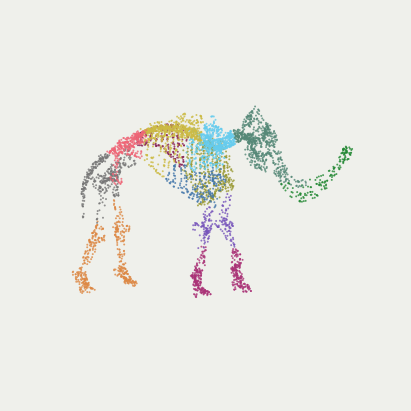

In [3]:
datasets = {}
for name in DATASETS:
    print(f"Preparing {name}…", flush=True)
    dataset = load_example_dataset(
        name, SOURCE_DATA, SAMPLE_SIZE, SEED,
        model_name=TEXT_MODEL,
        model_revision=TEXT_MODEL_REVISION, embedding_batch_size=EMBEDDING_BATCH_SIZE,
        embedding_device=EMBEDDING_DEVICE, max_seq_length=TEXT_MAX_SEQ_LENGTH,
    )
    datasets[name] = dataset
    settings = dict(dataset.preprocessing, requested_sample_size=SAMPLE_SIZE,
                    actual_sample_size=len(dataset.sample_ids))
    if "embedding_cache" in settings:
        settings["embedding_cache"] = str(Path(settings["embedding_cache"]).relative_to(PROJECT))
    (ARTIFACTS / f"{name}_preprocessing.json").write_text(json.dumps(settings, indent=2))
    print(f"{dataset.title}: {len(dataset.sample_ids):,} {dataset.noun}; "
          f"{dataset.features.shape[1]} feature dimensions", flush=True)
    display(pd.DataFrame({
        "class": dataset.class_names,
        "samples": np.bincount(dataset.labels, minlength=len(dataset.class_names)),
    }))
    display(pd.Series(settings, name="preprocessing"))

# Original geometry for interpreting the Mammoth colors and moving layouts.
if "mammoth" in datasets:
    mammoth = datasets["mammoth"]
    xyz = mammoth.extra_data[["x", "y", "z"]].astype(float).to_numpy()
    fig = plt.figure(figsize=(6, 4), layout="constrained")
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(*xyz.T, c=np.asarray(mammoth.colors)[mammoth.labels],
               s=2, alpha=.8, linewidths=0, depthshade=False)
    ax.set_box_aspect(np.ptp(xyz, axis=0))
    ax.view_init(elev=10, azim=-170)
    ax.set_axis_off()
    fig.savefig(DATA / "mammoth_3d_reference.png", dpi=160)
    display(HTML("<h3>Mammoth · original 3D point cloud</h3>"))
    plt.show()


## Fit one global-to-local sequence per dataset

With WARM_START=True, the first optimized layout starts from scaled PCA. Each subsequent fit uses a copy of the preceding **raw optimized coordinates at their existing scale**, without repeating early exaggeration. The **PCA regularization reference remains fixed**. Set WARM_START=False to compare independent fits from a common PCA initialization.

λ=1 is the analytic PCA endpoint; λ=0 disables the regularizer. The same observations, features, perplexity, and seed are used throughout each sweep. Cache keys include the features, observation IDs, optimizer settings, initialization policy, and ordered λ sequence. Each cache file records its actual initial coordinates and PCA reference, so partial runs resume consistently.

The pinned DREAMS fork forwards an unused X optimizer parameter. The experiment helper removes it on the prepared embedding and uses the public optimization API; neither DREAMS nor DataMapPlot is patched. Warm starts can reduce rearrangement, but results depend on the sweep direction and intermediate λ values.

In [4]:
def fit_dataset(name):
    dataset = datasets[name]
    print(f"Starting {dataset.title}: perplexity={PERPLEXITY}, warm_start={WARM_START}", flush=True)
    # Cache storage is isolated from the original perplexity-150 DREAMS fits.
    cache_root = DATA / "dreams-cache"
    if name != "fashion_mnist":
        cache_root = cache_root / name
    fitted = fit_dreams_spectrum(
        dataset.features, dataset.sample_ids, LAMBDAS, cache_root,
        seed=SEED, n_iter=N_ITER, n_jobs=N_JOBS,
        perplexity=PERPLEXITY, warm_start=WARM_START,
    )
    print(f"Finished {dataset.title}: {fitted[2]}", flush=True)
    return fitted

results = {}
with ThreadPoolExecutor(max_workers=min(PARALLEL_DATASETS, len(DATASETS))) as pool:
    futures = {name: pool.submit(fit_dataset, name) for name in DATASETS}
    for name in DATASETS:
        raw_layouts, fit_report, cache_directory = futures[name].result()
        results[name] = {
            "raw_layouts": raw_layouts, "fit_report": fit_report,
            "cache_directory": cache_directory,
        }

Starting Fashion-MNIST: perplexity=30, warm_start=True
Starting MNIST: perplexity=30, warm_start=True


λ=1: loaded cached layout (analytic PCA)


λ=1: loaded cached layout (analytic PCA)


λ=0.5: loaded cached layout (scaled PCA)


λ=0.5: loaded cached layout (scaled PCA)


...

λ=0.05: optimizing from lambda=0.15


Standard deviation of embedding is greater than 0.0001. Initial embeddings with high variance may have display poor convergence.


λ=0: optimizing from lambda=0.05


Standard deviation of embedding is greater than 0.0001. Initial embeddings with high variance may have display poor convergence.


Finished Mammoth: /Users/Noich001/Desktop/moving_data_mapplot/zoommap/dreams_p30/data/dreams-cache/mammoth/1844e1ea7682235c


## Align display coordinates and inspect quality

Center each layout, optionally equalize its RMS radius, and align its rotation to PCA without reflections. These operations happen outside DataMapPlot, and raw optimizer coordinates are preserved.

The quality table and slider both measure kNN recall at k=10 and Spearman correlation of pairwise distances for the same 1,000 fixed sampled observations used in the original slider metrics. These scores are added after the zoom path is built below. Both compare against each dataset's processed feature space, with no labels involved in the scoring. RMS motion measures displacement between adjacent aligned keyframes. These scores describe the computed layouts; interpolation does not perform another DREAMS optimization.

In [5]:
reports = []
for name in DATASETS:
    dataset, result = datasets[name], results[name]
    raw_layouts = result["raw_layouts"]
    layouts = align_for_display(raw_layouts, equalize_scale=EQUALIZE_SCALE)
    result["layouts"] = layouts
    report = result["fit_report"].copy()
    report.insert(0, "dataset", name)
    report["zoom_offset"] = ZOOM_OFFSETS
    report["rms_motion_to_next"] = [
        float(np.sqrt(np.mean(np.sum((b - a) ** 2, axis=1))))
        for a, b in zip(layouts[:-1], layouts[1:])
    ] + [np.nan]
    result["report"] = report
    reports.append(report)
    report.to_csv(ARTIFACTS / f"{name}_report.csv", index=False)
    np.savez_compressed(
        ARTIFACTS / f"{name}_layouts.npz",
        raw_positions=np.stack(raw_layouts), display_positions=np.stack(layouts),
        sample_ids=dataset.sample_ids, class_ids=dataset.labels,
        class_names=np.asarray(dataset.class_names),
        lambdas=LAMBDAS, zoom_offsets=ZOOM_OFFSETS,
        perplexity=PERPLEXITY, warm_start=WARM_START,
    )
    display(HTML(f"<h3>{dataset.title}</h3>"))
    display(report.round(3))
combined_report = pd.concat(reports, ignore_index=True)
combined_report.to_csv(ARTIFACTS / "general_example_report.csv", index=False)

,dataset,lambda,method,cached,compute_seconds,initialization,early_exaggeration_iter,perplexity,zoom_offset,rms_motion_to_next
0,fashion_mnist,1.00,PCA endpoint,True,0.000,analytic PCA,0,30,0.00,0.728
1,fashion_mnist,0.50,DREAMS,True,249.482,scaled PCA,250,30,0.70,0.554
2,fashion_mnist,0.25,DREAMS,True,156.194,lambda=0.5,0,30,1.05,0.363
3,fashion_mnist,0.15,DREAMS,True,319.112,lambda=0.25,0,30,1.25,0.935
4,fashion_mnist,0.05,DREAMS,True,149.781,lambda=0.15,0,30,1.55,0.776
5,fashion_mnist,0.00,t-SNE endpoint,True,152.525,lambda=0.05,0,30,2.50,NaN


,dataset,lambda,method,cached,compute_seconds,initialization,early_exaggeration_iter,perplexity,zoom_offset,rms_motion_to_next
0,mnist,1.00,PCA endpoint,True,0.000,analytic PCA,0,30,0.00,0.668
1,mnist,0.50,DREAMS,True,271.447,scaled PCA,250,30,0.70,0.493
2,mnist,0.25,DREAMS,True,164.835,lambda=0.5,0,30,1.05,0.385
3,mnist,0.15,DREAMS,True,322.004,lambda=0.25,0,30,1.25,0.561
4,mnist,0.05,DREAMS,True,152.254,lambda=0.15,0,30,1.55,0.384
5,mnist,0.00,t-SNE endpoint,True,155.379,lambda=0.05,0,30,2.50,NaN


,dataset,lambda,method,cached,compute_seconds,initialization,early_exaggeration_iter,perplexity,zoom_offset,rms_motion_to_next
0,20_newsgroups,1.00,PCA endpoint,True,0.000,analytic PCA,0,30,0.00,0.052
1,20_newsgroups,0.50,DREAMS,True,98.660,scaled PCA,250,30,0.70,0.046
2,20_newsgroups,0.25,DREAMS,True,47.593,lambda=0.5,0,30,1.05,0.022
3,20_newsgroups,0.15,DREAMS,True,46.872,lambda=0.25,0,30,1.25,0.053
4,20_newsgroups,0.05,DREAMS,True,46.431,lambda=0.15,0,30,1.55,0.038
5,20_newsgroups,0.00,t-SNE endpoint,True,46.010,lambda=0.05,0,30,2.50,NaN


,dataset,lambda,method,cached,compute_seconds,initialization,early_exaggeration_iter,perplexity,zoom_offset,rms_motion_to_next
0,mammoth,1.00,PCA endpoint,False,0.000,analytic PCA,0,30,0.00,6.971
1,mammoth,0.50,DREAMS,False,51.582,scaled PCA,250,30,0.70,5.641
2,mammoth,0.25,DREAMS,False,35.657,lambda=0.5,0,30,1.05,4.512
3,mammoth,0.15,DREAMS,False,35.280,lambda=0.25,0,30,1.25,9.875
4,mammoth,0.05,DREAMS,False,33.176,lambda=0.15,0,30,1.55,6.520
5,mammoth,0.00,t-SNE endpoint,False,34.882,lambda=0.05,0,30,2.50,NaN


## Compare the real keyframes

These panels show the actual computed layouts at a common display scale. Class/topic and Mammoth spatial-region colors are fixed across the sequence.

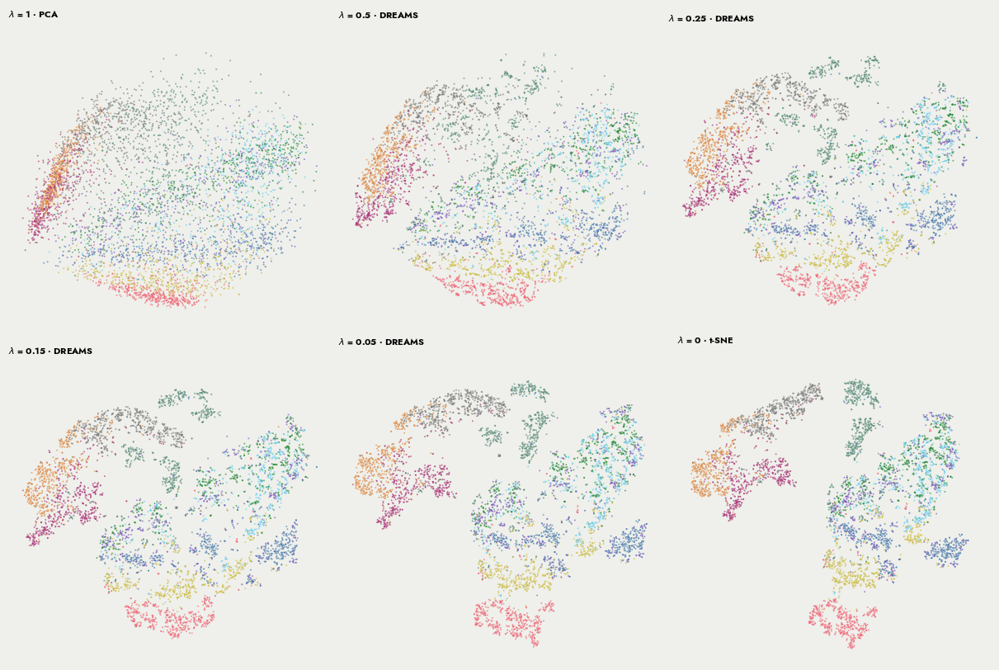

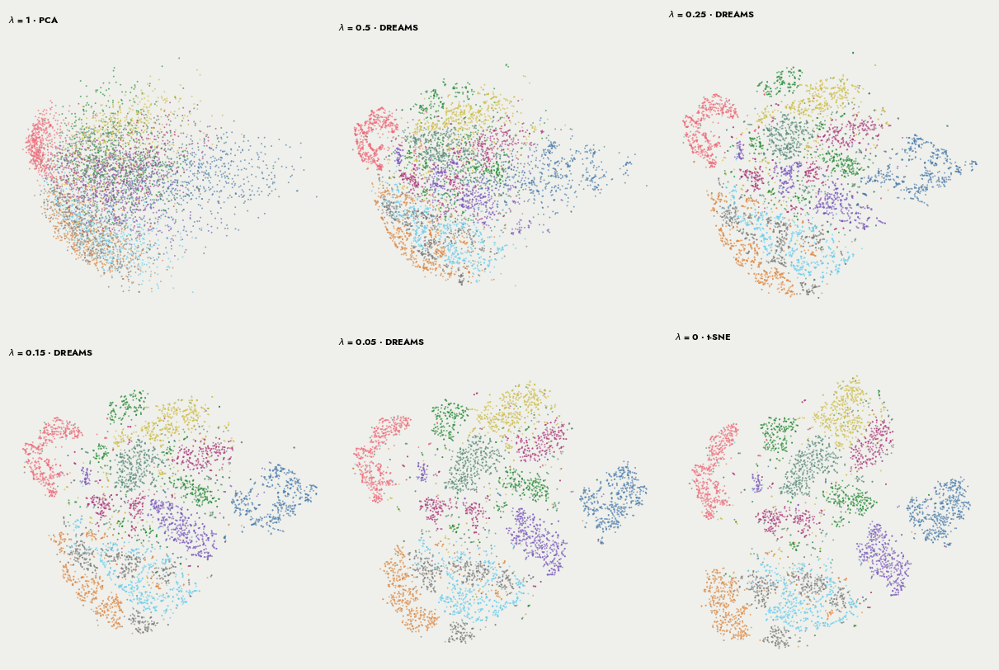

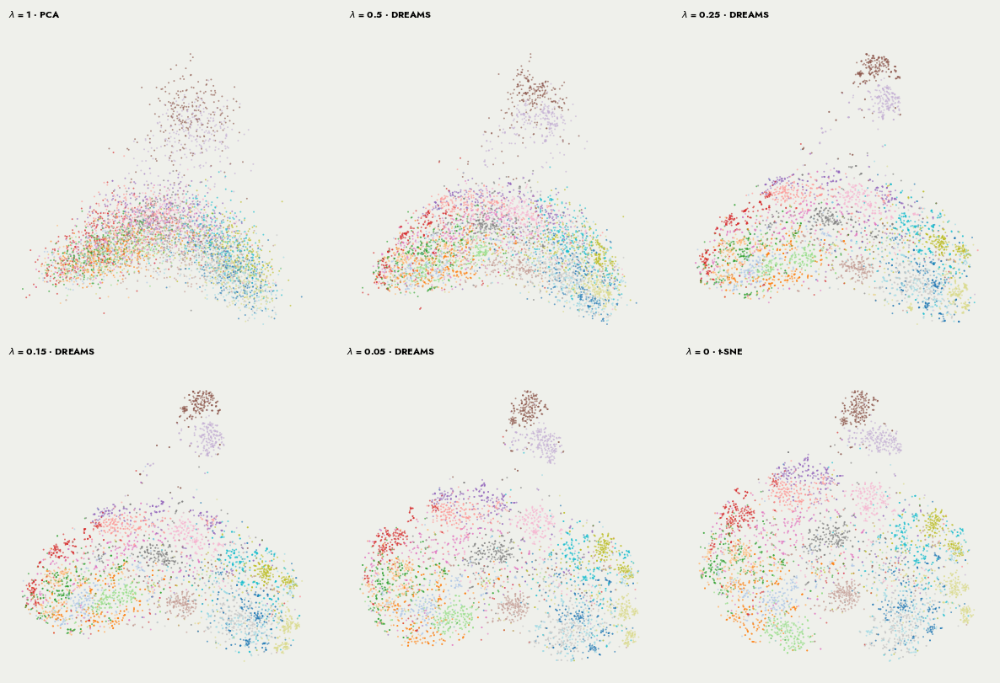

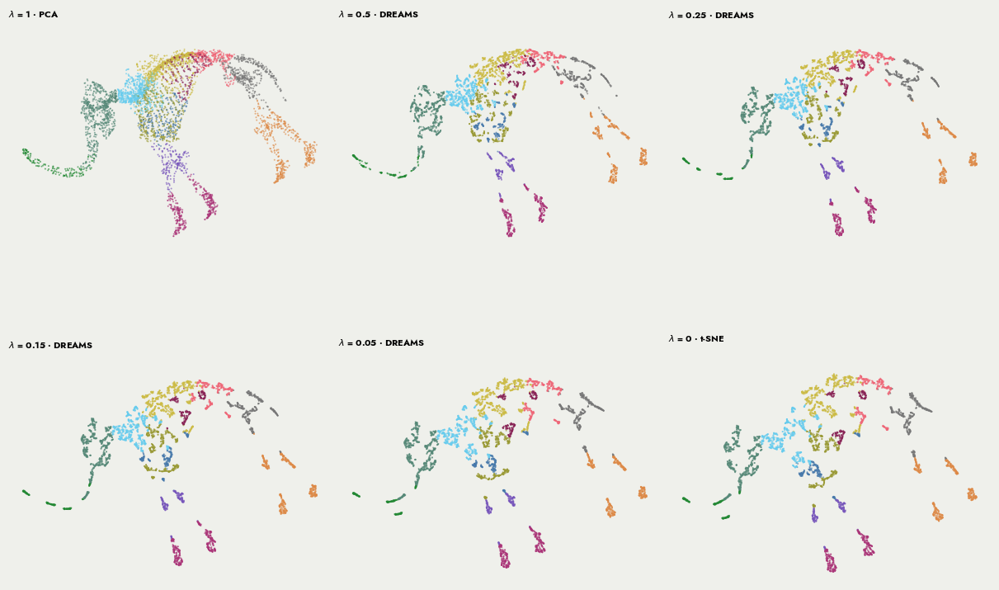

In [6]:
for name in DATASETS:
    dataset, result = datasets[name], results[name]
    class_colors = np.asarray(dataset.colors)[dataset.labels]
    result["class_colors"] = class_colors
    fig, axes = plt.subplots(2, 3, figsize=(12, 8), layout="constrained")
    for ax, positions, strength in zip(axes.flat, result["layouts"], LAMBDAS):
        ax.scatter(positions[:, 0], positions[:, 1], c=class_colors, s=2, alpha=.65, linewidths=0)
        method = "PCA" if strength == 1 else "t-SNE" if strength == 0 else "DREAMS"
        ax.set_title(f"$\\lambda$ = {strength:g} · {method}", fontsize=8)
        ax.set_aspect("equal")
        ax.set_axis_off()
    fig.savefig(DATA / f"{name}_keyframes.png", dpi=160)
    plt.show()

## Construct the ordered zoom keyframes

ZoomPositions accepts coordinates from any embedding method. Every frame must contain the same observations in the same row order. Zoom values can be unevenly spaced.

Linear interpolation takes straight segments. PCHIP uses a shape-preserving cubic on the actual zoom grid. Easing is independent: smoothstep or smootherstep stops movement at each knot. Per-interval options are also available through Transition objects.

In [7]:
for name in DATASETS:
    result = results[name]
    keyframes = [
        ZoomKeyframe(zoom, positions, f"λ={strength:g}")
        for zoom, positions, strength in zip(ZOOM_OFFSETS, result["layouts"], LAMBDAS)
    ]
    motion = ZoomPositions(keyframes, zoom_reference="initial",
                           interpolation=INTERPOLATION, easing=EASING)
    for frame in keyframes:
        np.testing.assert_allclose(motion.positions_at(frame.zoom), frame.positions, atol=1e-5)
    result.update(keyframes=keyframes, motion=motion)
    print(f"{datasets[name].title}: {len(keyframes)} keyframes, "
          f"{len(datasets[name].sample_ids):,} persistent point IDs")
    result["quality"] = evaluate_zoom_quality(
        datasets[name].features, datasets[name].sample_ids, motion,
        DATA / "quality-metrics" / name, seed=SEED,
        grid_size=QUALITY_GRID_SIZE, subset_size=QUALITY_SUBSET_SIZE,
    )
    quality_output = ARTIFACTS / "quality_metrics"
    quality_output.mkdir(exist_ok=True)
    (quality_output / f"{name}.json").write_text(json.dumps(result["quality"], indent=2))
    pd.DataFrame(result["quality"]["samples"]).to_csv(quality_output / f"{name}.csv", index=False)

    endpoints = pd.DataFrame(result["quality"]["samples"]).set_index("zoom").loc[ZOOM_OFFSETS]
    result["report"]["nn_recall"] = endpoints["nn_recall"].to_numpy()
    result["report"]["global_distance_spearman"] = endpoints["global_distance_spearman"].to_numpy()
    result["report"].to_csv(ARTIFACTS / f"{name}_report.csv", index=False)
combined_report = pd.concat([results[name]["report"] for name in DATASETS], ignore_index=True)
combined_report.to_csv(ARTIFACTS / "general_example_report.csv", index=False)
display(combined_report.round(3))


Fashion-MNIST: 6 keyframes, 5,000 persistent point IDs
Quality metrics: loaded 101 cached zoom samples


MNIST: 6 keyframes, 5,000 persistent point IDs
Quality metrics: loaded 101 cached zoom samples


20 Newsgroups · MPNet: 6 keyframes, 5,000 persistent point IDs
Quality metrics: loaded 101 cached zoom samples


Mammoth: 6 keyframes, 5,000 persistent point IDs
Quality metrics: evaluated 1/101 zoom samples


Quality metrics: evaluated 26/101 zoom samples


Quality metrics: evaluated 51/101 zoom samples


Quality metrics: evaluated 76/101 zoom samples


Quality metrics: evaluated 101/101 zoom samples


,dataset,lambda,method,cached,compute_seconds,initialization,early_exaggeration_iter,perplexity,zoom_offset,rms_motion_to_next,nn_recall,global_distance_spearman
0,fashion_mnist,1.00,PCA endpoint,True,0.000,analytic PCA,0,30,0.00,0.728,0.096,0.901
1,fashion_mnist,0.50,DREAMS,True,249.482,scaled PCA,250,30,0.70,0.554,0.419,0.879
2,fashion_mnist,0.25,DREAMS,True,156.194,lambda=0.5,0,30,1.05,0.363,0.495,0.854
3,fashion_mnist,0.15,DREAMS,True,319.112,lambda=0.25,0,30,1.25,0.935,0.507,0.838
4,fashion_mnist,0.05,DREAMS,True,149.781,lambda=0.15,0,30,1.55,0.776,0.512,0.786
5,fashion_mnist,0.00,t-SNE endpoint,True,152.525,lambda=0.05,0,30,2.50,NaN,0.512,0.735
6,mnist,1.00,PCA endpoint,True,0.000,analytic PCA,0,30,0.00,0.668,0.046,0.577
7,mnist,0.50,DREAMS,True,271.447,scaled PCA,250,30,0.70,0.493,0.320,0.543
8,mnist,0.25,DREAMS,True,164.835,lambda=0.5,0,30,1.05,0.385,0.444,0.507
9,mnist,0.15,DREAMS,True,322.004,lambda=0.25,0,30,1.25,0.561,0.458,0.482


## Export and display the interactive maps

This is the unchanged DataMapPlot function. ZoomPositions is passed through its existing custom_js parameter, alongside the optional example controls. Colors and image/document/XYZ metadata are supplied once and remain attached to point IDs. Automatic point sizing lets dots grow naturally as you zoom in.

Each exported HTML file embeds its coordinates, hover metadata and Opinionated’s bundled Jost font. The optional font helper removes duplicate Google Fonts declarations from the generated HTML before saving and displaying it. It runs without Python, but uses the normal DataMapPlot CDN dependencies.

The slider box displays the [DREAMS paper's section 5.1 metrics](https://arxiv.org/html/2508.13747#S5.SS1): **10-neighbor recall over every observation**, and **Spearman correlation of pairwise distances among 1,000 fixed randomly sampled observations**. Labels are unused. We evaluate the actual interpolated coordinates at a dense zoom grid and every fitted keyframe. The browser linearly looks up these quality samples; values between samples are approximate, marked ≈. Camera magnification and viewport cropping do not change these whole-layout scores. The new endpoint reports use these same 1,000-observation metrics. The original root example retains its legacy 700-observation endpoint CSVs; comparison below uses its 1,000-observation slider curves instead.


Saved /Users/Noich001/Desktop/moving_data_mapplot/zoommap/dreams_p30/artifacts/fashion_mnist_zoom.html (3.91 MB)


<InteractiveFigure width=100% height=800>
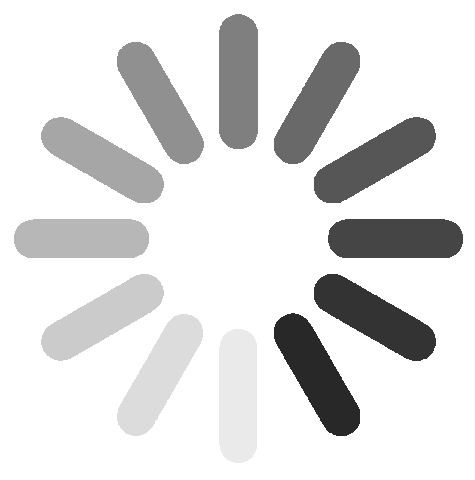

Saved /Users/Noich001/Desktop/moving_data_mapplot/zoommap/dreams_p30/artifacts/mnist_zoom.html (2.32 MB)


<InteractiveFigure width=100% height=800>
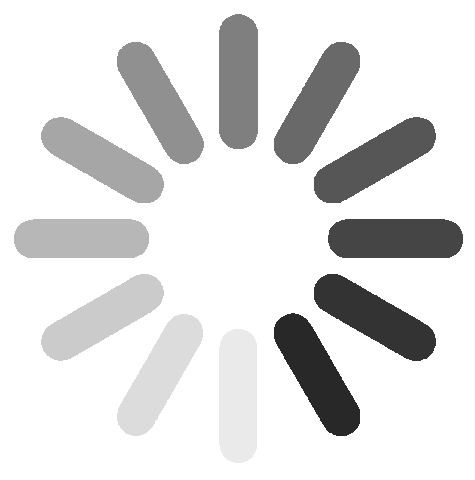

Saved /Users/Noich001/Desktop/moving_data_mapplot/zoommap/dreams_p30/artifacts/20_newsgroups_zoom.html (2.67 MB)


<InteractiveFigure width=100% height=800>
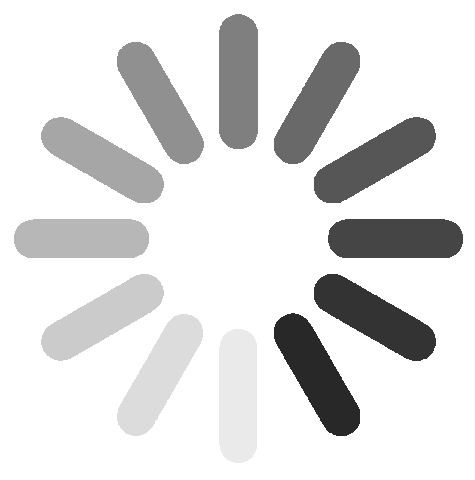

Saved /Users/Noich001/Desktop/moving_data_mapplot/zoommap/dreams_p30/artifacts/mammoth_zoom.html (0.91 MB)


<InteractiveFigure width=100% height=800>
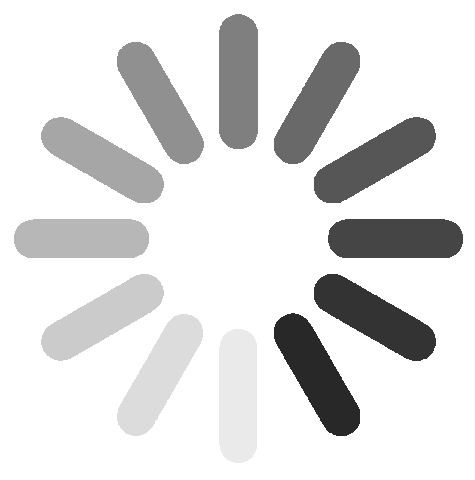

In [8]:
controls_js = (PROJECT / "notebooks" / "controls.js").read_text()
figures = {}
for name in DATASETS:
    dataset, result = datasets[name], results[name]
    custom_html, custom_css = plot_ui(
        dataset.title, len(dataset.sample_ids), dataset.noun,
        dataset.class_names, dataset.colors, PERPLEXITY,
    )
    figure = datamapplot.create_interactive_plot(
        result["layouts"][0], title=f"From global to local · {dataset.title}",
        marker_color_array=result["class_colors"],
        hover_text=[f"{dataset.class_names[int(label)]} · sample {index}"
                    for label, index in zip(dataset.labels, dataset.sample_ids)],
        extra_point_data=dataset.extra_data,
        hover_text_html_template=dataset.tooltip,
        point_radius_min_pixels=2.5, point_radius_max_pixels=10,
        point_size_scale=None, point_line_width=0,
        font_family=PLOT_FONT, tooltip_font_family=PLOT_FONT,
        background_color=PLOT_BACKGROUND, widgets=[], height=800,
        custom_html=custom_html, custom_css=custom_css,
        custom_js=result["motion"].to_javascript() + "\n" + controls_js + "\n" + quality_javascript(result["quality"]),
    )
    figure = use_bundled_jost(figure)
    output = ARTIFACTS / f"{name}_zoom.html"
    figure.save(str(output))
    figures[name] = figure
    print(f"Saved {output} ({output.stat().st_size / 1e6:.2f} MB)")
    display(HTML(f"<h3>{dataset.title}</h3>"))
    display(figure)

## Compare interpolation without recomputing embeddings

The following paths follow one original observation from each dataset. Both interpolation methods respect the same endpoints and uneven zoom grid. Edit the settings above and rerun the plotting cells to export another option; the expensive fits stay cached.

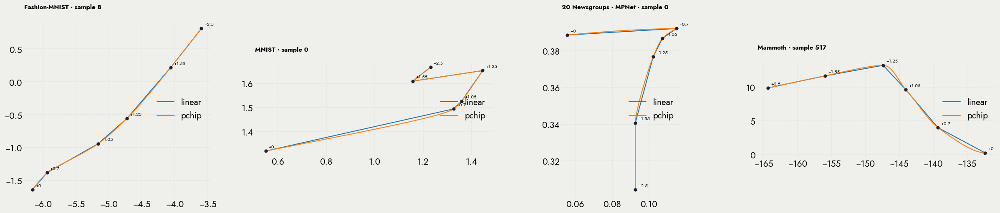

In [9]:
z = np.linspace(ZOOM_OFFSETS[0], ZOOM_OFFSETS[-1], 160)
fig, axes = plt.subplots(1, len(DATASETS), figsize=(6 * len(DATASETS), 5), squeeze=False, layout="constrained")
for ax, name in zip(axes.flat, DATASETS):
    dataset, result = datasets[name], results[name]
    probe = 0
    for method in ["linear", "pchip"]:
        path = ZoomPositions(result["keyframes"], interpolation=method)
        trajectory = np.asarray([path.positions_at(zoom)[probe] for zoom in z])
        ax.plot(trajectory[:, 0], trajectory[:, 1], label=method, linewidth=1.5)
    anchors = np.asarray([frame.positions[probe] for frame in result["keyframes"]])
    ax.scatter(anchors[:, 0], anchors[:, 1], color="#182238", s=24, zorder=3)
    for xy, zoom in zip(anchors, ZOOM_OFFSETS):
        ax.annotate(f"+{zoom:g}", xy, xytext=(5, 5), textcoords="offset points", fontsize=8)
    ax.set_title(f"{dataset.title} · sample {dataset.sample_ids[probe]}")
    ax.set_aspect("equal")
    ax.legend()
plt.show()

## Compare DREAMS perplexity 30 and 150

The preserved root slider curves and this variant use identical features, sample IDs, 10-neighbor definitions and the same 1,000 distance-reference observations. The table compares matching lambda/zoom anchors. Positive changes mean higher recall or distance correlation; these capture different qualities and should be considered together.

In [10]:
comparison = []
for name in DATASETS:
    original = json.loads((PROJECT / "artifacts" / "quality_metrics" / f"{name}.json").read_text())
    current = results[name]["quality"]
    assert original["metadata"] == current["metadata"], "Comparison needs identical feature and observation references"
    old = pd.DataFrame(original["samples"]).set_index("zoom").loc[ZOOM_OFFSETS]
    new = pd.DataFrame(current["samples"]).set_index("zoom").loc[ZOOM_OFFSETS]
    for i, strength in enumerate(LAMBDAS):
        comparison.append(dict(
            dataset=name, lambda_=strength, zoom_offset=ZOOM_OFFSETS[i],
            nn_recall_p150=old.iloc[i].nn_recall, nn_recall_p30=new.iloc[i].nn_recall,
            nn_recall_change=new.iloc[i].nn_recall-old.iloc[i].nn_recall,
            global_distance_spearman_p150=old.iloc[i].global_distance_spearman,
            global_distance_spearman_p30=new.iloc[i].global_distance_spearman,
            global_distance_spearman_change=new.iloc[i].global_distance_spearman-old.iloc[i].global_distance_spearman,
        ))
comparison = pd.DataFrame(comparison).rename(columns={"lambda_": "lambda"})
comparison.to_csv(ARTIFACTS / "perplexity_comparison.csv", index=False)
display(comparison.round(4))


,dataset,lambda,zoom_offset,nn_recall_p150,nn_recall_p30,nn_recall_change,global_distance_spearman_p150,global_distance_spearman_p30,global_distance_spearman_change
0,fashion_mnist,1.00,0.00,0.0960,0.0960,0.0000,0.9010,0.9010,0.0000
1,fashion_mnist,0.50,0.70,0.3520,0.4186,0.0666,0.8577,0.8788,0.0211
2,fashion_mnist,0.25,1.05,0.4007,0.4952,0.0945,0.7984,0.8539,0.0554
3,fashion_mnist,0.15,1.25,0.4123,0.5067,0.0944,0.7727,0.8381,0.0654
4,fashion_mnist,0.05,1.55,0.4207,0.5124,0.0917,0.7261,0.7860,0.0599
5,fashion_mnist,0.00,2.50,0.4224,0.5117,0.0893,0.7069,0.7353,0.0284
6,mnist,1.00,0.00,0.0462,0.0462,0.0000,0.5766,0.5766,0.0000
7,mnist,0.50,0.70,0.2628,0.3196,0.0568,0.5137,0.5434,0.0298
8,mnist,0.25,1.05,0.3671,0.4439,0.0768,0.4689,0.5070,0.0381
9,mnist,0.15,1.25,0.3926,0.4584,0.0658,0.4443,0.4821,0.0378


The extension updates scatter positions and retains colors, filter attributes, point indices, and hover metadata. Labels, hulls, density tiles, minimaps, annotations, and lasso spatial indices require their own position updates and are absent here.

Zoom changes magnification and layout; pan keeps the current layout. Points can move away from the location under the cursor. Interpolated layouts are visual approximations between the real optimizer outputs.

Exports live in artifacts/: one interactive HTML map, coordinate archive, preprocessing description, quality report per dataset, plus a combined quality table. Shared downloads, sentence embeddings and model weights stay in root data/. This variant has isolated optimizer, metric and plotting caches under dreams_p30/data/. The existing DREAMS fits remain separate; both notebooks also include the same Mammoth sample.